<a href="https://colab.research.google.com/github/diabateyoussouf/Daily-Data-Science/blob/main/dailly_08_dataset_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Étape 1 : Cadrage du Projet & Objectifs Métier

##  Contexte & Problématique
Dans un environnement d'entreprise, l'accès rapide et fiable à l'information interne (documentations techniques, rapports financiers, politiques RH, bases de connaissances) est un enjeu critique. Les moteurs de recherche par mots-clés traditionnels échouent à capturer le contexte sémantique, tandis que les Grands Modèles de Langue (LLMs) standards souffrent d'hallucinations et n'ont pas accès aux données privées ou récentes.

Ce projet met en œuvre une architecture **RAG (Retrieval-Augmented Generation)**. L'objectif est de coupler la puissance de compréhension d'un LLM avec une base de connaissances externe issue de Kaggle, garantissant des réponses précises, contextualisées et vérifiables (sourcées).

---

## Architecture du Pipeline RAG
Le système est découpé en 4 grands blocs techniques qui seront implémentés dans ce notebook :

1. **Ingestion & Segmentation (Chunking) :** Chargement du dataset textuel Kaggle et découpage intelligent des documents en segments optimisés pour maximiser le contexte sans dépasser la fenêtre de token du modèle.
2. **Vectorisation (Embeddings) :** Transformation des segments textuels en vecteurs sémantiques (dense vectors) capturant le sens profond des phrases.
3. **Stockage & Requêtage (Vector Database) :** Indexation des vecteurs dans une base de données vectorielle pour permettre une recherche de similarité cosinus ultra-rapide lorsqu'un utilisateur pose une question.
4. **Génération Contextuelle (LLM) :** Construction d'un prompt dynamique combinant la question de l'utilisateur et les segments pertinents récupérés, soumis au LLM pour générer la réponse finale.

---

## Métriques d'Évaluation du Système
Contrairement à la classification classique, un RAG s'évalue sur la qualité de son alignement à l'aide de deux concepts clés :
* **La Fidélité (Faithfulness) :** La réponse du LLM est-elle strictement basée sur les documents fournis ? (Avertissement anti-hallucination).
* **La Pertinence du Contexte (Answer Relevance) :** Les documents récupérés par le moteur de recherche répondent-ils vraiment à la question posée ?

In [1]:
import os
from google.colab import files

# Upload du token d'authentification Kaggle
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print(" Veuillez uploader votre fichier kaggle.json :")
    uploaded = files.upload()

    # Configuration des dossiers système pour Kaggle
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print(" Authentification Kaggle configurée avec succès !")
else:
    print(" Authentification Kaggle déjà active.")

# Téléchargement du dataset Single-Topic RAG via l'API
print(" Téléchargement du dataset en cours...")
!kaggle datasets download -d samuelmatsuoharris/single-topic-rag-evaluation-dataset

# Décompression de l'archive ZIP
print(" Décompression des fichiers...")
!unzip -o single-topic-rag-evaluation-dataset.zip -d ./rag_dataset

print("\n Fichiers prêts ! Voyons le contenu du dossier :")
!ls -l ./rag_dataset

 Veuillez uploader votre fichier kaggle.json :


Saving kaggle.json to kaggle.json
 Authentification Kaggle configurée avec succès !
 Téléchargement du dataset en cours...
Dataset URL: https://www.kaggle.com/datasets/samuelmatsuoharris/single-topic-rag-evaluation-dataset
License(s): MIT
100% 263k/263k [00:00<00:00, 85.8MB/s]

 Décompression des fichiers...
Archive:  single-topic-rag-evaluation-dataset.zip
  inflating: ./rag_dataset/documents.csv  
  inflating: ./rag_dataset/multi_passage_answer_questions.csv  
  inflating: ./rag_dataset/no_answer_questions.csv  
  inflating: ./rag_dataset/single_passage_answer_questions.csv  

 Fichiers prêts ! Voyons le contenu du dossier :
total 740
-rw-r--r-- 1 root root 721658 Apr 18  2025 documents.csv
-rw-r--r-- 1 root root  12370 Apr 18  2025 multi_passage_answer_questions.csv
-rw-r--r-- 1 root root   1826 Apr 18  2025 no_answer_questions.csv
-rw-r--r-- 1 root root   8940 Apr 18  2025 single_passage_answer_questions.csv


# **Visualisation des données**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import re

In [3]:
documents = pd.read_csv('/content/rag_dataset/documents.csv')
answers_questions = pd.read_csv('/content/rag_dataset/multi_passage_answer_questions.csv')
no_answer_questions = pd.read_csv('/content/rag_dataset/no_answer_questions.csv')
single_passage_answer_questions = pd.read_csv('/content/rag_dataset/single_passage_answer_questions.csv')

In [4]:
documents.head()

,index,source_url,text
0,0,https://enterthegungeon.fandom.com/wiki/Bullet...,Bullet Kin\nBullet Kin are one of the most com...
1,1,https://www.dropbox.com/scl/fi/ljtdg6eaucrbf1a...,---The Paths through the Underground/Underdark...
2,2,https://bytes-and-nibbles.web.app/bytes/stici-...,Semantic and Textual Inference Chatbot Interfa...
3,3,https://github.com/llmware-ai/llmware,llmware\n\nBuilding Enterprise RAG Pipelines w...
4,4,https://docs.marimo.io/recipes.html,Recipes\nThis page includes code snippets or “...


In [5]:
documents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   index       20 non-null     int64 
 1   source_url  20 non-null     object
 2   text        20 non-null     object
dtypes: int64(1), object(2)
memory usage: 612.0+ bytes


In [6]:
documents.describe().T

,count,mean,std,min,25%,50%,75%,max
index,20.0,9.5,5.91608,0.0,4.75,9.5,14.25,19.0


In [7]:
documents.shape

(20, 3)

In [8]:
# chercher max caracter dans la col text
MAX = documents['text'].str.len().max()

In [9]:
print("Le max caractère dans text: ",MAX)

Le max caractère dans text:  211782


In [10]:
answers_questions.head()

,document_index,question,answer
0,0,Which enemy types wield an AK-47?,Assault-rifle wielding Bullet and Tankers wiel...
1,0,What makes jammed enemies different?,"Jammed Keybullet Kin drop 2 keys instead of 1,..."
2,1,What enemies are encountered in the second enc...,26 kobolds and 1 kobold inventor are encounter...
3,1,What monsters are encountered in this journey?,"Ropers, kobolds, kobold inventors, fire giants..."
4,2,What framework was chosen to execute the RAG p...,The LangChain framework was used to orchestrat...


In [11]:
no_answer_questions.head()

,document_index,question
0,0,How much health does the Mutant Bullet Kin have?
1,0,Where can bishops be found?
2,1,What happened on day 10?
3,1,What did the goblins say?
4,2,Why was the H100 GPU chosen for computation?


In [12]:
single_passage_answer_questions.head()

,document_index,question,answer
0,0,What do keybullet kin drop?,Keybullet kin drop a key upon death.
1,0,What kind of gun does the bandana bullet kin use?,The bandana bullet kin wields a machine pistol.
2,1,What do the giants look like?,"One giant is burly, grey-skinned, and 20 feet ..."
3,1,What happens on day 2?,"After a few miles of winding tunnel, you emerg..."
4,2,What were the requirements for the project?,The tool had the following requirements:\n- Ch...


# **1. Ingestion & Segmentation (Chunking)**

In [13]:
!pip install -q langchain-text-splitters langchain-community sentence-transformers chromadb pypdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/7

### Import de toutes bibliothèques

In [14]:
# Découpage de texte (Nouveau package officiel)
from langchain_text_splitters import RecursiveCharacterTextSplitter
# Chargement de documents (Correction de la faute de frappe 'community')
from langchain_community.document_loaders import PyPDFDirectoryLoader, PyPDFLoader
# Stockage Vectoriel (Correction de 'vectorstores' et du chemin d'accès)
from langchain_community.vectorstores import Chroma
# Embeddings & LLM (Chemins officiels mis à jour)
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.llms import HuggingFacePipeline
from langchain_core.documents import Document

/tmp/ipykernel_7301/2095198462.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFDirectoryLoader, PyPDFLoader


In [15]:
pdf_file = "/content/rag_dataset/documents.csv"
#pdf_loader = PyPDFLoader(pdf_file)

In [16]:
df_docs = pd.read_csv(pdf_file)
# supprimer les doublons
df_docs = df_docs.drop_duplicates(subset=['text'])

# Conversion des lignes du CSV en objets Documents LangChain
langchain_docs = []
for idx, row in df_docs.iterrows():
    text_content = str(row['text']) if pd.notna(row['text']) else ""
    metadata = {"source_url": row['source_url']} if 'source_url' in df_docs.columns else {}
    langchain_docs.append(Document(page_content=text_content, metadata=metadata))

In [17]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base", # Encodage standard utilisé par gpt-3.5/gpt-4
    chunk_size=1000,             # 1000 tokens max par chunk
    chunk_overlap=200            # 200 tokens de chevauchement
)


In [18]:
# Découpage des documents
chunks = text_splitter.split_documents(langchain_docs)

In [19]:
print(f"Nombre de gros documents lus : {len(langchain_docs)}")
print(f"Nombre de morceaux (chunks) créés : {len(chunks)}")

Nombre de gros documents lus : 20
Nombre de morceaux (chunks) créés : 215


In [20]:
print(chunks[0])

page_content='Bullet Kin
Bullet Kin are one of the most common enemies. They slowly walk towards the player, occasionally firing a single bullet. They can flip tables and use them as cover. They will also deal contact damage if the player touches them.

Occasionally, Bullet Kin will have assault rifles, in which case they will rapidly fire 8 bullets towards the player before reloading. When an assault rifle wielding bullet kin appears, there will often be more in the same room.

On some occasions the player will also encounter incapacitated Bullet Kin lying on the floor. These Bullet Kin are props and disintegrate upon touch. They can be found in mass quantity in Oubliette.

In the Black Powder Mine, they can also ride Minecarts. In fact, if there are any unoccupied Minecarts within the room, they will take priority by walking towards them to ride in.

Trivia
Bullet Kin wield Magnums. Assault-rifle wielding Bullet Kin wield AK-47s.
Incapacitated Bullet Kin can be found in the Oublilett

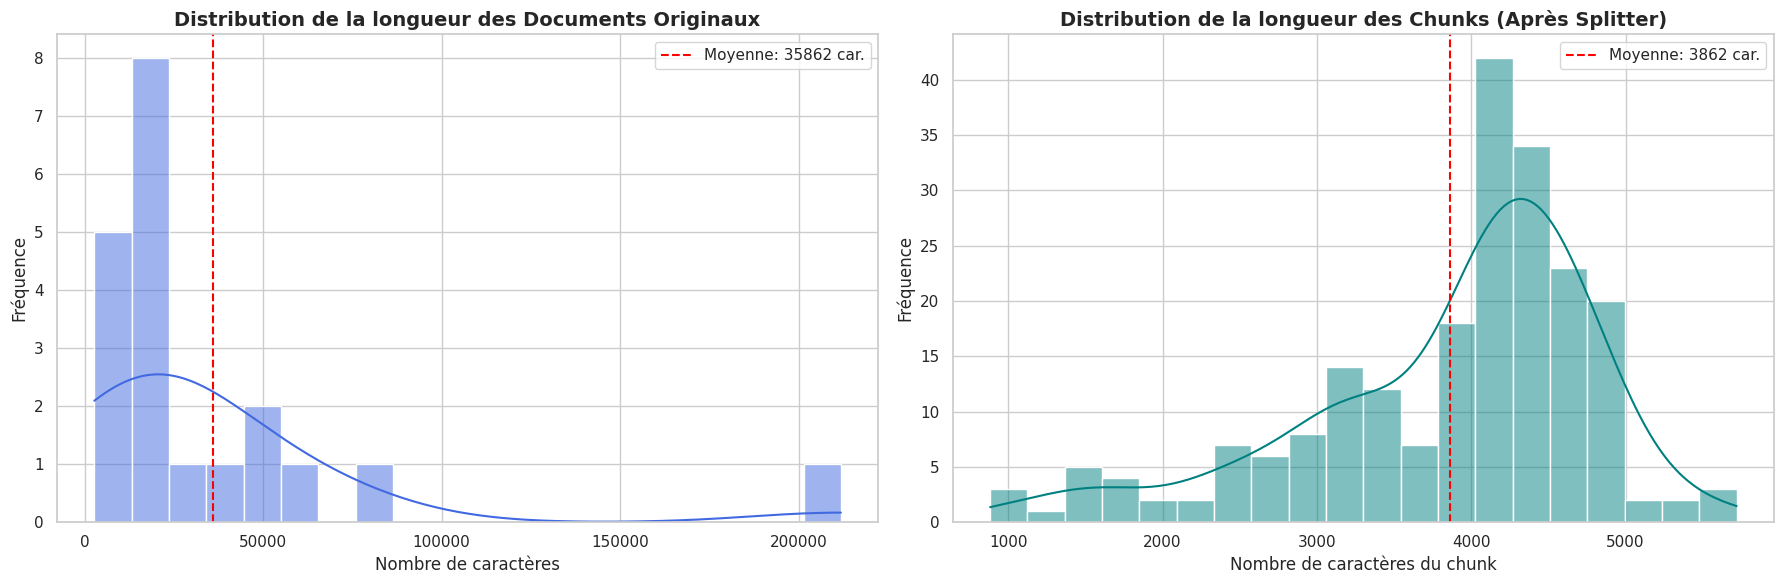


--- STATISTIQUES DES CHUNKS ---
🔹 Nombre total de chunks : 215
🔹 Longueur minimale d'un chunk : 883 caractères
🔹 Longueur maximale d'un chunk : 5720 caractères
🔹 Longueur moyenne d'un chunk : 3862.4 caractères


In [21]:
#  Calcul des longueurs (en caractères) des documents originaux
doc_lengths = [len(doc.page_content) for doc in langchain_docs]

# Calcul des longueurs (en caractères) des chunks générés
chunk_lengths = [len(chunk.page_content) for chunk in chunks]

# Configuration du style des graphiques
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# ---  Distribution des documents d'origine ---
plt.subplot(1, 2, 1)
sns.histplot(doc_lengths, bins=20, kde=True, color="royalblue")
plt.axvline(np.mean(doc_lengths), color="red", linestyle="--", label=f"Moyenne: {np.mean(doc_lengths):.0f} car.")
plt.title("Distribution de la longueur des Documents Originaux", fontsize=14, fontweight="bold")
plt.xlabel("Nombre de caractères")
plt.ylabel("Fréquence")
plt.legend()

# --- Distribution des Chunks après découpage ---
plt.subplot(1, 2, 2)
sns.histplot(chunk_lengths, bins=20, kde=True, color="teal")
plt.axvline(np.mean(chunk_lengths), color="red", linestyle="--", label=f"Moyenne: {np.mean(chunk_lengths):.0f} car.")
plt.title("Distribution de la longueur des Chunks (Après Splitter)", fontsize=14, fontweight="bold")
plt.xlabel("Nombre de caractères du chunk")
plt.ylabel("Fréquence")
plt.legend()

plt.tight_layout()
plt.show()

# --- Print des statistiques clés ---
print("\n--- STATISTIQUES DES CHUNKS ---")
print(f"🔹 Nombre total de chunks : {len(chunks)}")
print(f"🔹 Longueur minimale d'un chunk : {np.min(chunk_lengths)} caractères")
print(f"🔹 Longueur maximale d'un chunk : {np.max(chunk_lengths)} caractères")
print(f"🔹 Longueur moyenne d'un chunk : {np.mean(chunk_lengths):.1f} caractères")

# **2. Vectorisation (Embeddings)**

In [22]:
# Embdding model
embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")



/tmp/ipykernel_7301/1517977205.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# **3.Stockage & Requêtage (Vector Database)**

In [23]:
# base vectoriel
vector_store = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory="db",
    collection_name="rag_collection"
)

# algo de recherche
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 6}
)

Question posée : 'Which enemy types wield an AK-47?'

Réponse exacte :'Assault-rifle wielding Bullet and Tankers wield AK-47s.'

 --- ANALYSE DES CHUNKS RÉCUPÉRÉS ---
Réponse proposé par notre RAG

🔹 Chunk Rang #1 (Score de Distance : 1.0293)
🌐 Source URL : https://enterthegungeon.fandom.com/wiki/Bullet_Kin
📄 Contenu (Extrait) :
Bullet Kin
Bullet Kin are one of the most common enemies. They slowly walk towards the player, occasionally firing a single bullet. They can flip tables and use them as cover. They will also deal contact damage if the player touches them.

Occasionally, Bullet Kin will have assault rifles, in which ...
------------------------------------------------------------

🔹 Chunk Rang #2 (Score de Distance : 1.3100)
🌐 Source URL : https://enterthegungeon.fandom.com/wiki/Bullet_Kin
📄 Contenu (Extrait) :
Trivia
Although normally seen in the Abbey & Hollow, a single cardinal may be seen in the first floor, tending to a small cemetery filled with gravestones. He is the only

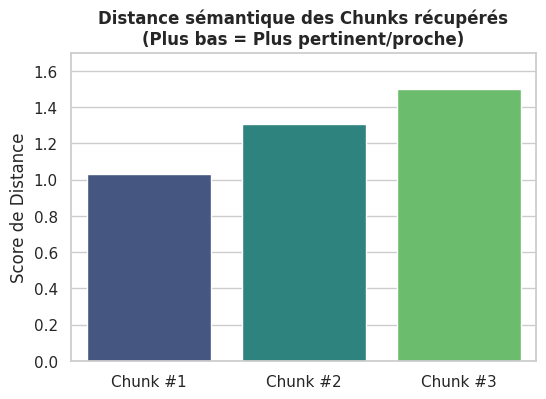

In [24]:
#  Prendre la question de test de ton dataset
ma_question = answers_questions.question[0]

resultats_avec_scores = vector_store.similarity_search_with_score(ma_question, k=3)

print(f"Question posée : '{ma_question}'\n")
print(f"Réponse exacte :'{answers_questions.answer[0]}'\n")
print(" --- ANALYSE DES CHUNKS RÉCUPÉRÉS ---")

indices = []
scores = []

print("Réponse proposé par notre RAG")
for i, (doc, score) in enumerate(resultats_avec_scores, 1):
    print(f"\n🔹 Chunk Rang #{i} (Score de Distance : {score:.4f})")
    print(f"🌐 Source URL : {doc.metadata.get('source_url', 'Inconnue')}")
    print(f"📄 Contenu (Extrait) :\n{doc.page_content[:300]}...")
    print("-" * 60)

    indices.append(f"Chunk #{i}")
    scores.append(score)

#  Graphique d'évaluation de la confiance du Retrieval
plt.figure(figsize=(6, 4))
# Utilisation d'une palette standard pour éviter les avertissements de Seaborn
sns.barplot(x=indices, y=scores, hue=indices, palette="viridis", legend=False)
plt.title("Distance sémantique des Chunks récupérés\n(Plus bas = Plus pertinent/proche)", fontsize=12, fontweight="bold")
plt.ylabel("Score de Distance")
plt.ylim(0, max(scores) + 0.2 if scores else 1)
plt.show()

# **4. Génération Contextuelle (LLM)**

In [25]:
!pip install -q langchain-mistralai

In [28]:
import os
import shutil
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import HumanMessage, AIMessage

In [29]:
os.environ["MISTRAL_API_KEY"] = "eSElIPMWJOaKKPI86JsvwkvszE3ZzkOj"

llm = ChatMistralAI(
    model="mistral-large-latest",
    temperature=0.1,
    max_tokens=500
)

In [33]:
# Template pour générer une requête de recherche autonome à partir de l'historique
CONDENSE_TEMPLATE = """Given the following conversation history and a follow-up question, rephrase the follow-up question to be a standalone question, in English, that includes all necessary context for a document search.
Do not answer the question, just rephrase it.

HISTORY:
{chat_history}

FOLLOW-UP QUESTION: {question}
STANDALONE QUESTION:"""

# Template final pour la génération de la réponse
PROMPT_TEMPLATE = """Tu es un assistant virtuel expert doté de mémoire. Réponds à la question de l'utilisateur en te basant exclusivement sur le contexte fourni et l'historique de la conversation.
Si la réponse n'est pas dans le contexte, dis simplement que tu ne sais pas. Ne cherche pas à inventer ou à utiliser tes connaissances générales si le contexte est vide.

HISTORIQUE DE LA CONVERSATION :
{chat_history}

CONTEXTE DE RECHERCHE TECHNIQUE :
{context}

QUESTION : {question}
RÉPONSE :"""


# =====================================================================
# FONCTIONS DE L'AGENT
# =====================================================================

def get_vectorstore():
    """Retourne l'instance globale du vector store Chroma."""
    return vector_store


def agent(user_question, history):
    try:
        vectorstore = get_vectorstore()
    except Exception as e:
        return f" Erreur d'initialisation de la base : {str(e)}"

    # Construction de l'historique sous forme de texte
    chat_history_str = ""
    for msg in history[-10:]:
        if isinstance(msg, HumanMessage):
            chat_history_str += f"Question: {msg.content}\n"
        elif isinstance(msg, AIMessage):
            chat_history_str += f"Réponse: {msg.content}\n\n"

    if not chat_history_str:
        chat_history_str = "No history yet."

    # Reformulation automatique de la question pour le Retriever via l'historique
    search_query = user_question
    if history:
        condense_prompt = CONDENSE_TEMPLATE.format(
            chat_history=chat_history_str,
            question=user_question
        )
        search_query = llm.invoke(condense_prompt).content

    # Récupération des documents pertinents avec la requête reformulée (sans filtres superflus)
    retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 4})
    relevant_docs = retriever.invoke(search_query)

    context = " ".join([doc.page_content.replace('\n', ' ') for doc in relevant_docs])

    # Génération de la réponse finale basée sur le contexte épuré
    prompt = PROMPT_TEMPLATE.format(
        chat_history=chat_history_str,
        context=context,
        question=user_question
    )

    response = llm.invoke(prompt)
    return response.content if hasattr(response, 'content') else str(response)

In [36]:
# Initialisation d'un historique de discussion vide
mon_historique = []

# =====================================================================
# --- PREMIER ÉCHANGE ---
# =====================================================================
q1 = "Which enemy types wield an AK-47?"

print(f"Question : {q1}")
r1 = agent(q1, mon_historique)
print(f"Réponse : {r1}")

# Mise à jour de l'historique
mon_historique.append(HumanMessage(content=q1))
mon_historique.append(AIMessage(content=r1))

print("\n" + "-"*60 + "\n")

# =====================================================================
# --- DEUXIÈME ÉCHANGE (Utilisation de la mémoire) ---
# =====================================================================
q2 = "Can you tell me more about the first one you mentioned?"

print(f"Question : {q2}")
r2 = agent(q2, mon_historique)
print(f"Réponse : {r2}")

Question : Which enemy types wield an AK-47?
Réponse : D'après le contexte fourni, les ennemis qui wieldent un AK-47 sont :

- **Assault-rifle wielding Bullet Kin** (les Bullet Kin équipés de fusils d'assaut)
- **Tankers**

------------------------------------------------------------

Question : Can you tell me more about the first one you mentioned?
Réponse : D'après le contexte fourni, voici les détails concernant le premier ennemi mentionné précédemment, à savoir **l'Assault-rifle wielding Bullet Kin** (Bullet Kin équipé d'un AK-47) :

- **Comportement** :
  - Il se déplace lentement vers le joueur, comme les Bullet Kin classiques.
  - Il tire **8 balles rapidement** en rafale avant de devoir recharger.
  - Lorsqu'un Bullet Kin équipé d'un AK-47 apparaît, il est souvent accompagné d'autres ennemis du même type dans la même pièce.

- **Particularités** :
  - Il utilise un **AK-47** (mentionné explicitement dans la section *Trivia*).
  - Contrairement aux Bullet Kin standards (qui uti

# **5. Métriques d'Évaluation du Système**

In [42]:
import pandas as pd
import time
from langchain_core.messages import HumanMessage

# Sélectionner un échantillon réduit
test_df = single_passage_answer_questions.head(5).copy()

evaluation_data = []

print("Génération des réponses de l'agent pour l'évaluation...")

for idx, row in test_df.iterrows():
    question = row['question']
    ground_truth = row['answer']

    print(f"Traitement de la question {idx + 1}/{len(test_df)}...")

    try:
        # Récupération du contexte via le vector store
        vectorstore = get_vectorstore()
        retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 4})
        relevant_docs = retriever.invoke(question)
        contexts = [doc.page_content for doc in relevant_docs]

        # Appel de ton agent avec le BON nom de fonction
        generated_answer = agent(question, [])

        # Stockage si succès
        evaluation_data.append({
            "question": question,
            "contexts": contexts,
            "answer": generated_answer,
            "ground_truth": ground_truth
        })

    except Exception as e:
        print(f" Erreur sur la ligne {idx + 1} : {str(e)}")
        # En cas d'erreur soft, on met un placeholder pour ne pas tout perdre
        evaluation_data.append({
            "question": question,
            "contexts": [],
            "answer": "Erreur API / Limite atteinte",
            "ground_truth": ground_truth
        })

    # secondes pour réinitialiser les quotas de l'API Mistral
    time.sleep(5)

# Conversion en DataFrame
eval_df = pd.DataFrame(evaluation_data)
print("\nDataset d'évaluation créé avec succès ! Tu peux passer à l'étape suivante.")

Génération des réponses de l'agent pour l'évaluation...
Traitement de la question 1/5...
Traitement de la question 2/5...
Traitement de la question 3/5...
Traitement de la question 4/5...
Traitement de la question 5/5...

Dataset d'évaluation créé avec succès ! Tu peux passer à l'étape suivante.


In [43]:
import time
from langchain_mistralai import ChatMistralAI

# Initialisation d'un modèle plus léger pour le Juge (évite les blocages 429)
llm_juge = ChatMistralAI(
    model="open-mistral-7b",
    temperature=0.0,
    api_key=os.getenv("MISTRAL_API_KEY") or "PhWAtaf81BWvQEyU5xD0RzKeiPj3xifX"
)

# Prompts de notation
FAITHFULNESS_JUDGE = """En tant que juge IA, évalue si la RÉPONSE est strictement basée sur le CONTEXTE fourni.
Donne uniquement un score décimal entre 0 et 1 (ex: 1.0, 0.5, 0.0). 1.0 signifie que tout est vrai et vérifiable, 0.0 signifie qu'il y a une hallucination totale.
Ne donne aucune explication, juste le chiffre.

CONTEXTE : {context}
RÉPONSE : {answer}
SCORE :"""

RELEVANCE_JUDGE = """En tant que juge IA, évalue si le CONTEXTE fourni contient les informations nécessaires pour répondre à la QUESTION.
Donne uniquement un score décimal entre 0 et 1 (ex: 1.0, 0.5, 0.0). 1.0 signifie que le contexte est parfait, 0.0 signifie qu'il est totalement hors-sujet.
Ne donne aucune explication, juste le chiffre.

QUESTION : {question}
CONTEXTE : {context}
SCORE :"""

faithfulness_scores = []
relevance_scores = []

print(" Analyse des métriques par le LLM Juge (avec sécurité anti-429)...")

for idx, row in eval_df.iterrows():
    print(f" Évaluation de la ligne {idx + 1}/{len(eval_df)}...")

    # Si la ligne a échoué à l'étape précédente, on met des scores à 0
    if row['answer'] == "Erreur API / Limite atteinte":
        faithfulness_scores.append(0.0)
        relevance_scores.append(0.0)
        continue

    context_str = " ".join(row['contexts'])

    # Évaluation de la Fidélité
    try:
        p_faith = FAITHFULNESS_JUDGE.format(context=context_str, answer=row['answer'])
        score_faith = float(llm_juge.invoke(p_faith).content.strip())
    except:
        score_faith = 0.5
    faithfulness_scores.append(score_faith)

    # Petite pause entre les deux évaluations de la même ligne
    time.sleep(3)

    # Évaluation de la Pertinence
    try:
        p_relev = RELEVANCE_JUDGE.format(question=row['question'], context=context_str)
        score_relev = float(llm_juge.invoke(p_relev).content.strip())
    except:
        score_relev = 0.5
    relevance_scores.append(score_relev)

    # GROSSE PAUSE : 10 secondes pour laisser expirer le Rate Limit de l'API
    time.sleep(10)

# Injection des scores
eval_df['faithfulness'] = faithfulness_scores
eval_df['context_relevance'] = relevance_scores

# 3. Affichage du Rapport Final
print("\n==================================================")
print("  RAPPORT D'ÉVALUATION DU SYSTÈME RAG      ")
print("==================================================")
print(f"Fidélité Moyenne (Anti-Hallucination) : {eval_df['faithfulness'].mean():.2f} / 1.00")
print(f"Pertinence Moyenne du Contexte         : {eval_df['context_relevance'].mean():.2f} / 1.00")
print("==================================================")

 Analyse des métriques par le LLM Juge (avec sécurité anti-429)...
 Évaluation de la ligne 1/5...
 Évaluation de la ligne 2/5...
 Évaluation de la ligne 3/5...
 Évaluation de la ligne 4/5...
 Évaluation de la ligne 5/5...

  RAPPORT D'ÉVALUATION DU SYSTÈME RAG      
Fidélité Moyenne (Anti-Hallucination) : 0.40 / 1.00
Pertinence Moyenne du Contexte         : 0.54 / 1.00


# Conclusion : ça sera mieux trouver param optimal ou changer embedding par un embedding plus fort afin d'avoir, le melleur score.